In [1]:
from astropy.io import fits
from astropy import units, constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

Load in STIS LSF

In [3]:
lsf_fits_stis = fits.open(rootdir + 'STIS/PG1522_STIS_NUV_wavcal2022_lsf.fits')

In [4]:
lsf_fits_stis[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  

In [5]:
lsf_fits_stis[0].data

In [6]:
lsf_fits_stis[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  200 / length of dimension 1                          
NAXIS2  =                    1 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'wave    '                                                            
TFORM1  = 'K       '                                                            
TTYPE2  = 'dv      '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'lsf     '        

In [7]:
lsf_fits_stis[1].data

FITS_rec([(2400, 4.9, [3.31816036e-44, 1.03829623e-36, 6.27906947e-30, 7.33870454e-24, 1.65765299e-18, 7.23632303e-14, 6.10509425e-10, 9.95444163e-07, 3.13683402e-04, 1.91036468e-02, 2.24849084e-01, 5.11465179e-01, 2.24849084e-01, 1.91036468e-02, 3.13683402e-04, 9.95444163e-07, 6.10509425e-10, 7.23632303e-14, 1.65765299e-18, 7.33870454e-24, 6.27906947e-30, 1.03829623e-36, 3.31816036e-44])],
         dtype=(numpy.record, [('wave', '>i8'), ('dv', '>f8'), ('lsf', '>f8', (23,))]))

Isolate the data - some reference wavelength, velocity scale, LSF array

In [8]:
lsf_stis_data = lsf_fits_stis[1].data

In [9]:
wav0_stis = lsf_stis_data[0][0]
dv_stis = lsf_stis_data[0][1]
lsf_arr_stis = lsf_stis_data[0][2]

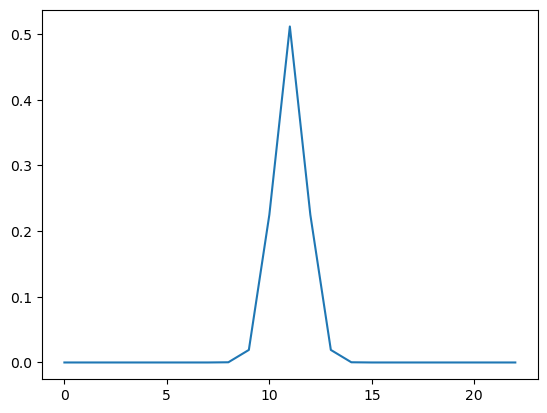

In [10]:
plt.plot(lsf_arr_stis)

In [17]:
np.sum(lsf_arr_stis), dv_stis*len(lsf_arr_stis)

(1.0, 112.7)

Prepare for STIS LSF

In [12]:
wav0_hires = 4440
dv_hires = 1.30

In [21]:
n_pix = dv_stis*len(lsf_arr_stis)//dv_hires + 1

http://personal.psu.edu/jtw13/rvworkshop/presentation/1-b-Howard-HIRES.pdf, LSF FWHM also taken from Sankar et al. 2020

In [22]:
fwhm_hires = 6.6
sigma_hires = fwhm_hires/(2*np.sqrt(2*np.log(2)))

In [31]:
x = np.arange(-n_pix//2*dv_hires, n_pix//2*dv_hires, dv_hires)

In [34]:
lsf_arr_hires = np.exp(-0.5*x**2)
lsf_arr_hires /= np.sum(lsf_arr_hires)

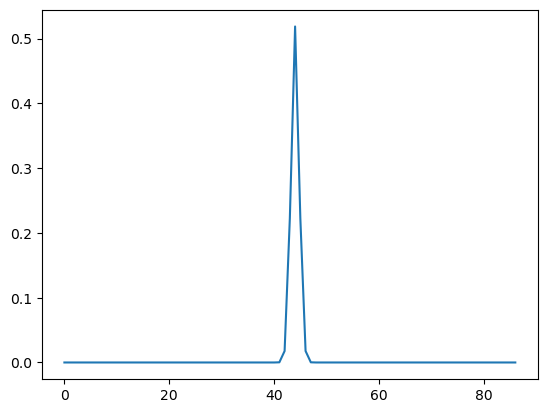

In [35]:
plt.plot(lsf_arr_hires)

In [56]:
len(lsf_arr_hires)

87

In [223]:
c1 = fits.Column(name='wave    ', format='K', array=[wav0_hires])
c2 = fits.Column(name='dv      ', format='D', array=[dv_hires])
c3 = fits.Column(name='lsf     ', format='87D')

In [225]:
table_hdu = fits.BinTableHDU.from_columns([c1,c2,c3], nrows=1)

In [226]:
table_hdu.data[0][2] = lsf_arr_hires

In [227]:
table_hdu.data

FITS_rec([(4440, 1.3, [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 1.21799071e-309, 1.00794700e-288, 1.53912447e-268, 4.33662747e-249, 2.25461719e-230, 2.16289699e-212, 3.82861050e-195, 1.25051487e-178, 7.53665890e-163, 8.38129613e-148, 1.71983125e-133, 6.51182639e-120, 4.54948372e-107, 5.86494230e-095, 1.39510758e-083, 6.12341898e-073, 4.95932512e-063, 7.41128494e-054, 2.04365116e-045, 1.03983001e-037, 9.76248220e-031, 1.69122149e-024, 5.40608719e-019, 3.18865791e-014, 3.47036487e-010, 6.96922801e-007, 2.58247743e-004, 1.76575612e-002, 2.22775400e-001, 5.18616188e-001, 2.22775400e-001, 1.76575612e-002, 2.58247743e-004, 6.96922801e-007, 3.47036487e-010, 3.18865791e-014, 5.40608719e-019, 1.69122149e-024, 9.76248220e-031, 1.03983001e-037, 2.04365116e-045, 7.41128494e-054, 4.959325

In [229]:
hdu = fits.HDUList([lsf_fits_stis[0], table_hdu])

In [230]:
hdu.writeto(rootdir +'HIRES/PG1522_HIRES_wavcal2023_lsf.fits')